Start by importing libraries and data

In [1]:
#import likely useful libraries
import numpy as np
import pandas as pd
import datetime as dt
import os

In [2]:
#confirm directory
os.listdir()

['.ipynb_checkpoints',
 'corr_heatmap.png',
 'create_source.png',
 'invited.png',
 'mail.png',
 'market.png',
 'org_size.png',
 'relax.ipynb',
 'relax_data_science_challenge.pdf',
 'takehome_users.csv',
 'takehome_user_engagement.csv']

In [3]:
#import Data
dfUser = pd.read_csv('takehome_users.csv', encoding='latin-1')
dfEngage = pd.read_csv('takehome_user_engagement.csv')

In [4]:
#inspect data
dfUser.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [5]:
#inspect data
dfEngage.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


The user data does not have an "adopted" feature, so we have to first calculate that using the data in the engagement dataframe, then add it to the user dataframe. The first step is to convert the timestamp into a datetime object

In [6]:
#convert time_stamp to datetime object
dfEngage['time_stamp'] = pd.to_datetime(dfEngage['time_stamp'])

In [7]:
dfEngage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   time_stamp  207917 non-null  datetime64[ns]
 1   user_id     207917 non-null  int64         
 2   visited     207917 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 4.8 MB


Next, we will see if we can get the visit count for each user. Since we are interested in the time, just the day, we will create another column that extracts just the date, then group the number of visits per each user

In [8]:
#extract just the date
dfEngage['date'] = dfEngage['time_stamp'].dt.date
#group number of visits by user id
visits_per_day = dfEngage.groupby('user_id').size().reset_index(name='visit_count')

In [9]:
visits_per_day.head()

,user_id,visit_count
0,1,1
1,2,14
2,3,1
3,4,1
4,5,1


An adopted user has to have visited at least 3 times, so we will filter them into a new dataframe

In [10]:
#filter out users with less than 3 visits
visit_3 = visits_per_day[visits_per_day['visit_count']>=3]
visit_3.head()

,user_id,visit_count
1,2,14
7,10,284
13,20,7
24,33,18
28,42,342


An adopted user also has to have the 3 visits be within a seven day period, so now we have to find the timeframe and adjust the code to account for this

In [11]:
#convert date object to datetime
dfEngage['date'] = pd.to_datetime(dfEngage['date'])

#use describe to see first and last date
dfEngage.describe()

,time_stamp,user_id,visited,date
count,207917,207917.000000,207917.0,207917
mean,2013-10-30 05:06:45.648763648,5913.314197,1.0,2013-10-29 16:42:23.861252352
min,2012-05-31 08:20:06,1.000000,1.0,2012-05-31 00:00:00
25%,2013-07-16 20:17:21,3087.000000,1.0,2013-07-16 00:00:00
50%,2013-12-03 06:38:34,5682.000000,1.0,2013-12-03 00:00:00
75%,2014-03-13 08:00:24,8944.000000,1.0,2014-03-13 00:00:00
max,2014-06-06 14:58:50,12000.000000,1.0,2014-06-06 00:00:00
std,NaN,3394.941674,0.0,NaN


In [12]:
#see if we can groupby a specific 7 day period
start = pd.to_datetime('2014-02-02')
end = start + pd.Timedelta(days=7)
mask = (dfEngage['date'] >= start) & (dfEngage['date'] <= end)
user_per_day = dfEngage[mask].groupby('user_id').size().reset_index(name='visit_count')
user_per_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      1150 non-null   int64
 1   visit_count  1150 non-null   int64
dtypes: int64(2)
memory usage: 18.1 KB


In [13]:
#filter by users with greater than 3 visits
user_3 = user_per_day[user_per_day['visit_count']>=3]
user_3.info()
user_3.head()

<class 'pandas.core.frame.DataFrame'>
Index: 660 entries, 0 to 1148
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      660 non-null    int64
 1   visit_count  660 non-null    int64
dtypes: int64(2)
memory usage: 15.5 KB


,user_id,visit_count
0,2,3
1,10,4
2,42,4
3,63,8
5,69,7


Now that we can find a list of users for a specific 7 day period, we can wrap this code in a function to select any 7 day period

In [14]:
#put the above into a function to select any 7 day period
import pandas as pd

def adopted(df, start_date):
    ### get the number of users with 3 or more visits within a 7 day period###
    # Convert start_date to datetime
    start = pd.to_datetime(start_date)
    end = start + pd.Timedelta(days=7)
    
    #Filter to the 7‑day window
    mask = (df['date'] >= start) & (df['date'] <= end)
    df_range = df[mask]
    
    #Count visits per user
    user_counts = (df_range.groupby('user_id').size().reset_index(name='visit_count'))
    
    # Return only users with 3+ visits
    return user_counts[user_counts['visit_count'] >= 3]    

In [15]:
#sanity check to confirm it works
adopted(dfEngage, '2014-02-03')

,user_id,visit_count
0,2,3
1,10,4
3,42,5
4,63,8
6,69,6
...,...,...
1143,11909,5
1148,11957,5
1149,11959,3
1152,11969,6


Now we can use this function to loop through every 7 day period within the 2 year timeframe

In [16]:
#loop through each 7 day period
start_date = dfEngage['date'].min()
final_date = dfEngage['date'].max() - pd.Timedelta(days=7)

results = {}

current_start = start_date

while current_start <= final_date:
    users = adopted(dfEngage, current_start)
    results[current_start.strftime("%Y-%m-%d")] = users
    current_start += pd.Timedelta(days=1)


In [17]:
#sanity check to confirm it works
results["2014-02-03"]

,user_id,visit_count
0,2,3
1,10,4
3,42,5
4,63,8
6,69,6
...,...,...
1143,11909,5
1148,11957,5
1149,11959,3
1152,11969,6


Next we can combine all the results into 1 dataframe to prepare to add it to the user info dataframe

In [18]:
#combine all dictionaries into 1 dataframe
combined = pd.concat(results.values(), ignore_index=True)
adopted_user = combined[['user_id']].drop_duplicates()
adopted_user.head()

,user_id
0,1693
4,728
5,1525
9,11764
11,6886


Now that we know which users are considered adopted users, we can add this as a target feature to work on identifying future user adoption

In [19]:
#remove duplicates
adopted_set = set(adopted_user['user_id'])

#add adopted column to user dataframe
dfUser['adopted'] = dfUser['object_id'].isin(adopted_set).astype(int)


We can now take an overview of the data by using the head, info, and desribe methods

In [20]:
dfUser.head(10)

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,1
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,0
5,6,2013-12-17 03:37:06,Cunha Eduardo,EduardoPereiraCunha@yahoo.com,GUEST_INVITE,1.387424e+09,0,0,197,11241.0,0
6,7,2012-12-16 13:24:32,Sewell Tyler,TylerSewell@jourrapide.com,SIGNUP,1.356010e+09,0,1,37,NaN,0
7,8,2013-07-31 05:34:02,Hamilton Danielle,DanielleHamilton@yahoo.com,PERSONAL_PROJECTS,NaN,1,1,74,NaN,0
8,9,2013-11-05 04:04:24,Amsel Paul,PaulAmsel@hotmail.com,PERSONAL_PROJECTS,NaN,0,0,302,NaN,0
9,10,2013-01-16 22:08:03,Santos Carla,CarlaFerreiraSantos@gustr.com,ORG_INVITE,1.401833e+09,1,1,318,4143.0,1


In [21]:
dfUser.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
 10  adopted                     12000 non-null  int32  
dtypes: float64(2), int32(1), int64(4), object(4)
memory usage: 984.5+ KB


In [22]:
dfUser.describe()

,object_id,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted
count,12000.00000,8.823000e+03,12000.000000,12000.000000,12000.000000,6417.000000,12000.000000
mean,6000.50000,1.379279e+09,0.249500,0.149333,141.884583,5962.957145,0.138000
std,3464.24595,1.953116e+07,0.432742,0.356432,124.056723,3383.761968,0.344914
min,1.00000,1.338452e+09,0.000000,0.000000,0.000000,3.000000,0.000000
25%,3000.75000,1.363195e+09,0.000000,0.000000,29.000000,3058.000000,0.000000
50%,6000.50000,1.382888e+09,0.000000,0.000000,108.000000,5954.000000,0.000000
75%,9000.25000,1.398443e+09,0.000000,0.000000,238.250000,8817.000000,0.000000
max,12000.00000,1.402067e+09,1.000000,1.000000,416.000000,11999.000000,1.000000


The creation time is currently an object, so we need to convert it to a datetime, and add an additional unix timestamp so we have it as a numeric column as well (for use later when looking at correlations)

In [23]:
#convert creation time to datetime and create an addition unix timestamp column
dfUser['creation_time'] = pd.to_datetime(dfUser['creation_time'])
dfUser["creation_unix"] = dfUser["creation_time"].astype("int64") // 10**9

We see missing values in last_session_creation_time and invited_by_user_id. The NaN for invited by user means they signed up on their own, without a user inviting them, so we can create a 'fake' user to denote this. We will impute user_id "0" for all of these, then create another binary column to denote invited or not invited. An NaN for last session creation time means they never logged in after creating an account. We will create an additional binary column of 'never logged in' to capture this information .

In [24]:
dfUser['invited_by_user_id']= dfUser['invited_by_user_id'].fillna(0)
dfUser['invited'] = (dfUser["invited_by_user_id"] > 0).astype(int)
dfUser["never_logged_in"] = dfUser["last_session_creation_time"].isna().astype(int)



In [25]:
dfUser.head(10)

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted,creation_unix,invited,never_logged_in
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,0,1398138810,1,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,1,1384487104,1,0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,0,1363734892,1,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,0,1369123768,1,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,0,1358417660,1,0
5,6,2013-12-17 03:37:06,Cunha Eduardo,EduardoPereiraCunha@yahoo.com,GUEST_INVITE,1.387424e+09,0,0,197,11241.0,0,1387251426,1,0
6,7,2012-12-16 13:24:32,Sewell Tyler,TylerSewell@jourrapide.com,SIGNUP,1.356010e+09,0,1,37,0.0,0,1355664272,0,0
7,8,2013-07-31 05:34:02,Hamilton Danielle,DanielleHamilton@yahoo.com,PERSONAL_PROJECTS,NaN,1,1,74,0.0,0,1375248842,0,1
8,9,2013-11-05 04:04:24,Amsel Paul,PaulAmsel@hotmail.com,PERSONAL_PROJECTS,NaN,0,0,302,0.0,0,1383624264,0,1
9,10,2013-01-16 22:08:03,Santos Carla,CarlaFerreiraSantos@gustr.com,ORG_INVITE,1.401833e+09,1,1,318,4143.0,1,1358374083,1,0


Now that we have cleaner data, we can explore it further and visualize it using plots. We can start with looking at the correlation between numeric features

In [26]:
#import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

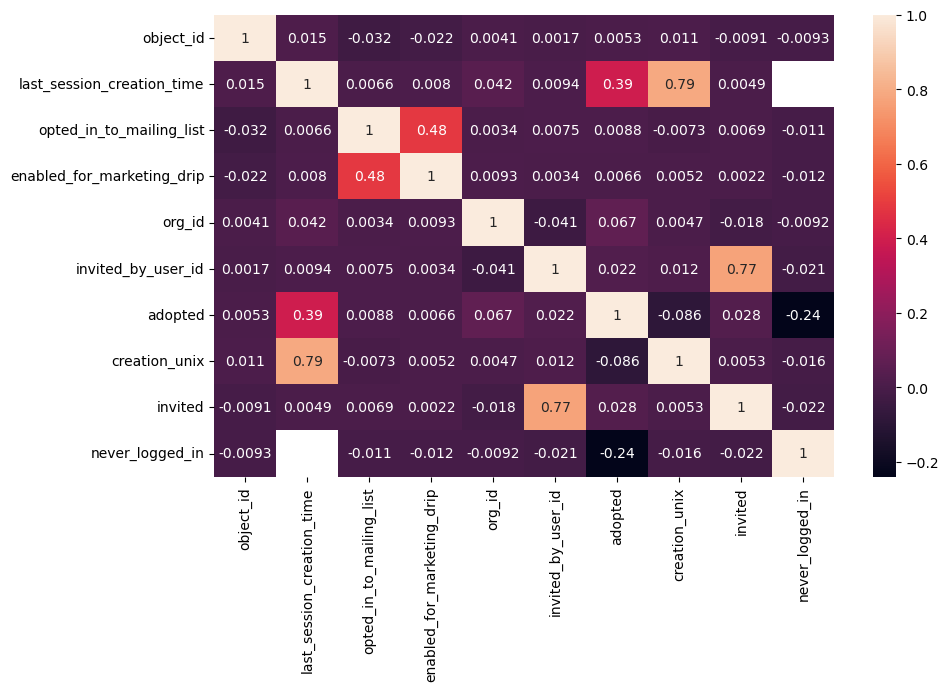

In [27]:
corr = dfUser.corr(numeric_only=True)
# Plot heatmap 
plt.figure(figsize=(10, 6)) 
sns.heatmap(corr, annot=True) 
plt.savefig("corr_heatmap.png", bbox_inches="tight")
plt.show()

The heatmap shows us various pieces of information, but we are mainly concerned with features that correleate with the 'adopted' target. The main item is the posistive correlation of .39 with last_session_creation_time, indicating that the more recent a user logged in, the more likely they are to be an adopted user. The other item, which may be obvious is the negative correlation with never_logged_in, which makes sense. Users that created an acount but did not log in are not going to be adopted users. lastly, we can see that wile the opting into the mailing list and enabling the market drip are correlated with each other, they do not have a correlation with user adoption, which means they are not useful predictors of user adoption.

Now we look at categorical features

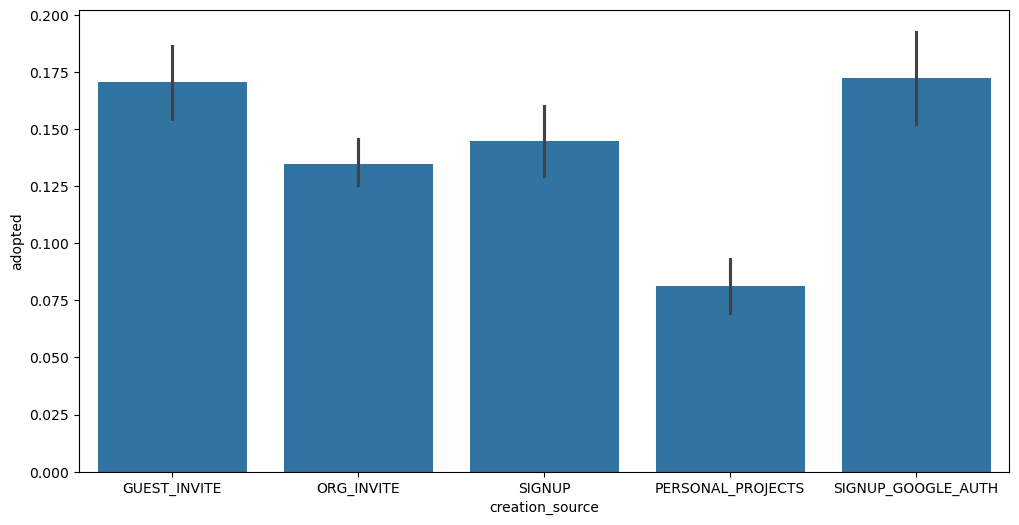

In [31]:
#creation source
plt.figure(figsize=(12, 6)) 
sns.barplot( data=dfUser, x="creation_source", y="adopted")
plt.savefig('create_source.png', bbox_inches="tight")


In [29]:
#calculate the percentage of adopted based on creation source

yn_creation = dfUser.groupby('creation_source')['adopted'].value_counts().unstack().reset_index()
yn_creation['percent_Y'] = (yn_creation[1] / (yn_creation[1] + yn_creation[0])) * 100
yn_creation.sort_values('percent_Y', ascending = False)

adopted,creation_source,0,1,percent_Y
4,SIGNUP_GOOGLE_AUTH,1146,239,17.256318
0,GUEST_INVITE,1794,369,17.059639
3,SIGNUP,1785,302,14.470532
1,ORG_INVITE,3680,574,13.493183
2,PERSONAL_PROJECTS,1939,172,8.147797


Based on the above, we can see that users with a higher intent and easier signup are more likely to be adopted users. Google authentication users are intentionally signing up for the product, and is usually the easiest/ quickest way to create an account. Guest invites are also higher, likely due to them being invited for a specific purpose and use of the product. Org invites are lower, possibly due to bulk invites from the organization with users that might not need to use the product themselves. Lastly, users added to another user's workspace do not necessarily have an intent to use the product, as they were pulled in by someone else.

Since google signup and geust invite are very close to each other, we can look at the "invited" feature to see if it gives us any additional information. Invited would include guest invite, and org invite, while google, signup, and personal projects would fall under not invited

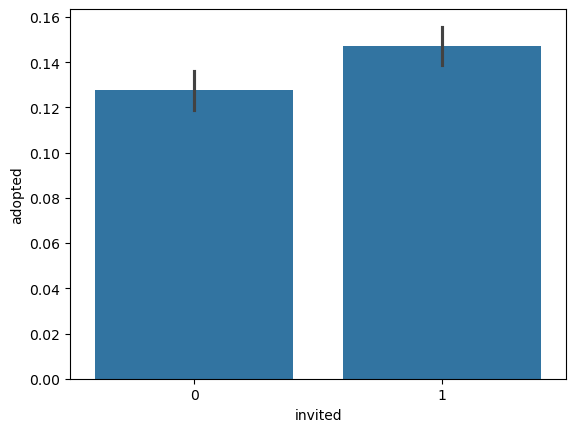

In [32]:
#invited
sns.barplot( data=dfUser, x="invited", y="adopted" )
plt.savefig('invited.png', bbox_inches="tight")


In [33]:
#calculate the percentage of adopted based on creation source
yn_invited = dfUser.groupby('invited')['adopted'].value_counts().unstack().reset_index()
yn_invited['percent_Y'] = (yn_invited[1] / (yn_invited[1] + yn_invited[0])) * 100
yn_invited.sort_values('percent_Y', ascending = False)

adopted,invited,0,1,percent_Y
1,1,5474,943,14.695341
0,0,4870,713,12.770912


we can see that there is a slightly greater percentage of adoption among invited users, but with only ~2% difference, this feature is likely not really usful in predicting user adoption

we already saw in the correlation heatmap that mailing list and marketing drip did not have any correlation to adoption, but let us plot just to see what it looks like

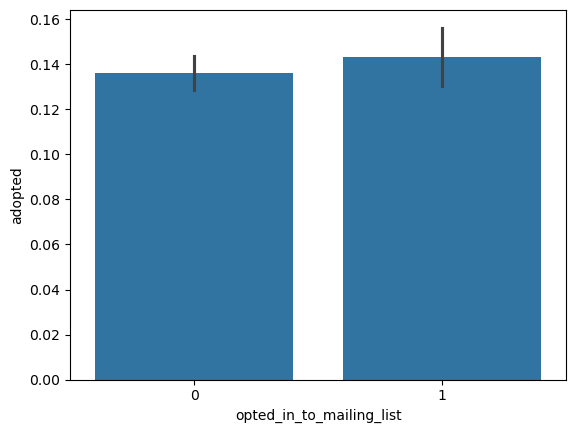

In [34]:
#mailing list
sns.barplot( data=dfUser, x="opted_in_to_mailing_list", y="adopted" )
plt.savefig('mail.png', bbox_inches="tight")


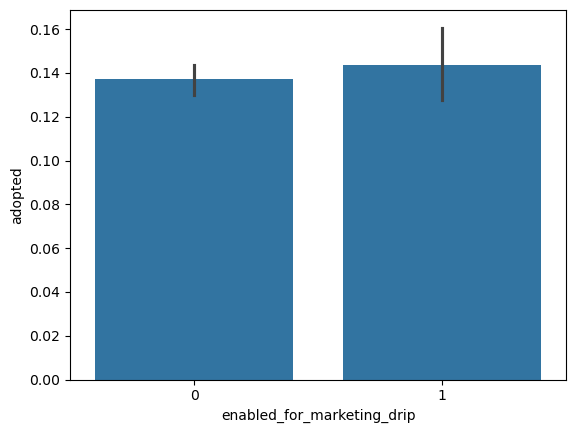

In [35]:
#marketing
sns.barplot( data=dfUser, x="enabled_for_marketing_drip", y="adopted" )
plt.savefig('market.png', bbox_inches="tight")

similar to the 'invited' feature, both of these feature give a slight edge to user who opt in. However, the difference is even smaller than it was with the 'invited' feature, so as we confirmed before, these feature are not useful for predicting user adoption.

<Axes: xlabel='org_id', ylabel='adopted'>

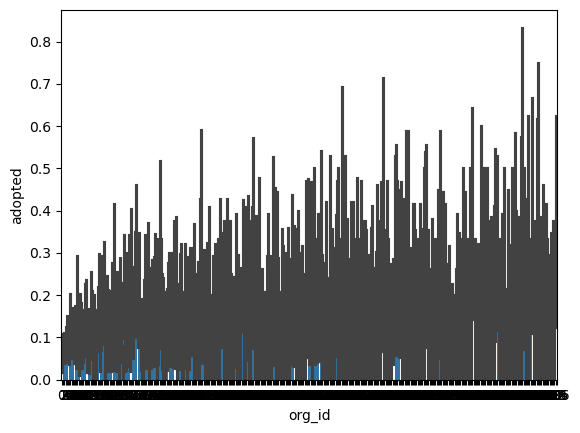

In [36]:
#org_id
sns.barplot( data=dfUser, x="org_id", y="adopted" )

There are too many organization ids to make the plot readable, let's see if we can find information a different way. To start, let's see how many different organizations there are

In [37]:
dfUser['org_id'].nunique()

417

instead of a plot, we can still do the calculations mathematically instead of visually

In [57]:
#calculate the percentage of adopted based on org id

yn_org = dfUser.groupby('org_id')['adopted'].value_counts().unstack().reset_index()
yn_org['percent_Y'] = (yn_org[1] / (yn_org[1] + yn_org[0])) * 100
yn_org["total_users"] = yn_org[0] + yn_org[1]
yn_org = yn_org.sort_values('percent_Y', ascending = False)


In [40]:
yn_org.describe()

adopted,org_id,0,1,percent_Y,total_users
count,417.000000,417.000000,401.000000,401.000000,401.000000
mean,208.000000,24.805755,4.129676,16.108374,29.341646
std,120.521782,25.768630,2.608283,7.877381,27.936812
min,0.000000,2.000000,1.000000,2.631579,7.000000
25%,104.000000,14.000000,2.000000,10.526316,17.000000
50%,208.000000,18.000000,3.000000,14.814815,23.000000
75%,312.000000,25.000000,5.000000,20.000000,30.000000
max,416.000000,307.000000,17.000000,58.333333,319.000000


We can see that the percent adopted ranges from 2.6% up to 58.3%, however, with total users per organization ranging from 7 to 319, this might not be us useful as it looks. For example, if an organization has 2 users and 1 is an adopted user, the adoption rate is 50%, whereas if a company has 200 users, it would need 100 of them to be considered adopted users in order to reach the same percentage. So instead, we will investigate this further.

<Axes: >

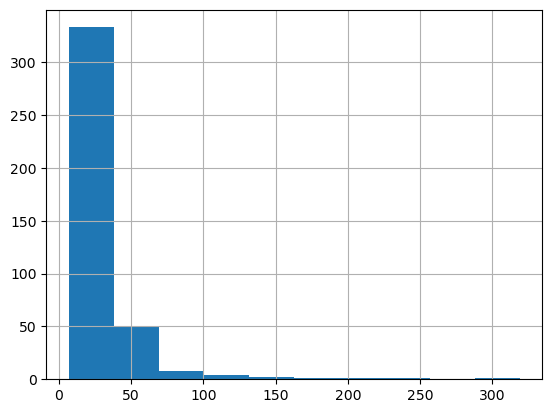

In [59]:
yn_org['total_users'].hist()

In [58]:
yn_org.head(10)

adopted,org_id,0,1,percent_Y,total_users
387,387,5.0,7.0,58.333333,12.0
235,235,7.0,6.0,46.153846,13.0
270,270,8.0,6.0,42.857143,14.0
399,399,8.0,5.0,38.461538,13.0
415,415,10.0,6.0,37.500000,16.0
392,392,10.0,6.0,37.500000,16.0
400,400,5.0,3.0,37.500000,8.0
117,117,14.0,8.0,36.363636,22.0
345,345,9.0,5.0,35.714286,14.0
318,318,11.0,6.0,35.294118,17.0


looking at the histogram of users per organization, we can see a heavily right skewed distribution. Looking at the hieghest percentage of adopted users per organization, we can see that they are all around the same size. Based on this, we can create another feature by separating the organizations into 4 groups based on size. We can base the sizes to be roughly around the quartiles. 

In [60]:
bins = [0, 15, 25, 40, yn_org.total_users.max()]
labels = ["very_small", "small", "medium", "large"]

yn_org["size_group"] = pd.cut(yn_org["total_users"], bins=bins, labels=labels)


In [61]:
yn_org.groupby("size_group",observed=True)["percent_Y"].mean()

size_group
very_small    19.708582
small         16.534402
medium        15.635916
large         11.243413
Name: percent_Y, dtype: float64

We can see that organizations with a smaller amount of total users have a higher percentage of user adoption. Now let's plot this to see it visually. We will try a barplot and a boxplot

<Axes: xlabel='size_group', ylabel='percent_Y'>

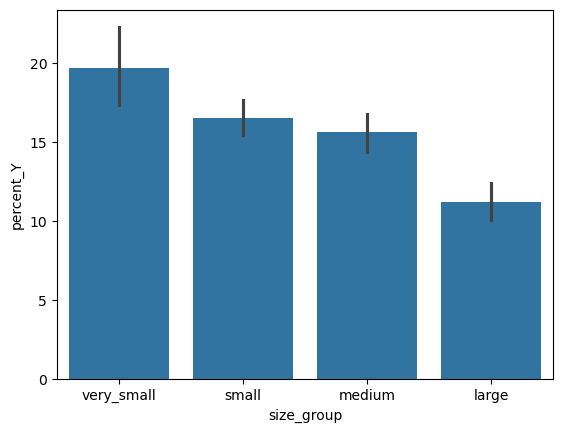

In [63]:
sns.barplot(data=yn_org, x="size_group", y="percent_Y")

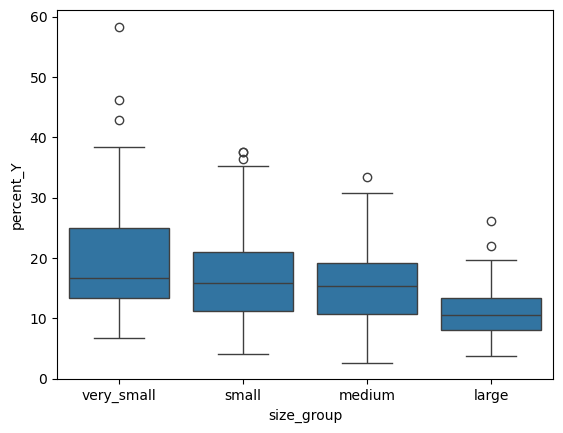

In [62]:
sns.boxplot(data=yn_org, x="size_group", y="percent_Y")
plt.savefig('org_size.png', bbox_inches="tight")


The boxplot works better in showing more useful information. And as we noticed before, smaller organizations are more likely to have adopted users.